In [2]:
import pandas as pd 

In [3]:
df = pd.read_csv("C:/Users/USER/Downloads/2026_빅콘/notebooks/page2/clustering/gu_features_with_card_2024.csv")

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ============================================================
# 1. 클러스터링 변수 선택
# ============================================================
# 핵심: 총량 원변수보다 비율/구조 변수 중심
# 카드소비는 log_consumption_total 사용

features = [
    # 생활인구 구조
    "L1_work_home_ratio",
    "L2_weekend_active_ratio",
    "weekend_home_ratio",

    # 산업구조
    "B1_avg_emp_per_biz",
    "B2_office_emp_ratio_no_support",   # 있으면 이걸 우선 사용
    "B3_consumption_tourism_emp_ratio",
    "B4_life_service_emp_ratio",
    "B5_industrial_logistics_emp_ratio",
]

# 없으면 자동 제외
features = [c for c in features if c in df.columns]

print("사용 변수:")
for c in features:
    print("-", c)

model_df = df[["gu"] + features].dropna().copy()

print("분석 대상:", model_df.shape)
display(model_df)

사용 변수:
- L1_work_home_ratio
- L2_weekend_active_ratio
- weekend_home_ratio
- B1_avg_emp_per_biz
- B2_office_emp_ratio_no_support
- B3_consumption_tourism_emp_ratio
- B4_life_service_emp_ratio
- B5_industrial_logistics_emp_ratio
분석 대상: (25, 9)


,gu,L1_work_home_ratio,L2_weekend_active_ratio,weekend_home_ratio,B1_avg_emp_per_biz,B2_office_emp_ratio_no_support,B3_consumption_tourism_emp_ratio,B4_life_service_emp_ratio,B5_industrial_logistics_emp_ratio
0,종로구,1.639698,0.795812,1.120581,5.672325,0.307603,0.270190,0.158138,0.132324
1,중구,2.064828,0.629787,1.083157,5.960833,0.410461,0.276900,0.074487,0.119097
2,용산구,1.184049,0.975406,1.076227,5.656782,0.311226,0.344603,0.141911,0.084112
3,성동구,1.092607,0.911819,0.982540,5.119779,0.264219,0.266925,0.150575,0.206280
4,광진구,0.937800,1.047381,0.982846,3.768584,0.143997,0.298187,0.273648,0.181917
5,동대문구,0.982189,0.977135,0.971601,3.378678,0.124829,0.317755,0.284616,0.179222
6,중랑구,0.847549,1.097254,0.967456,2.727116,0.076985,0.272712,0.268140,0.302640
7,성북구,0.897531,1.021568,0.951521,3.531200,0.122407,0.262859,0.367205,0.155216
8,강북구,0.873287,1.080638,0.976905,2.953737,0.107578,0.302779,0.294023,0.199744
9,도봉구,0.866140,1.096668,0.978875,3.165744,0.118359,0.249941,0.315619,0.194613


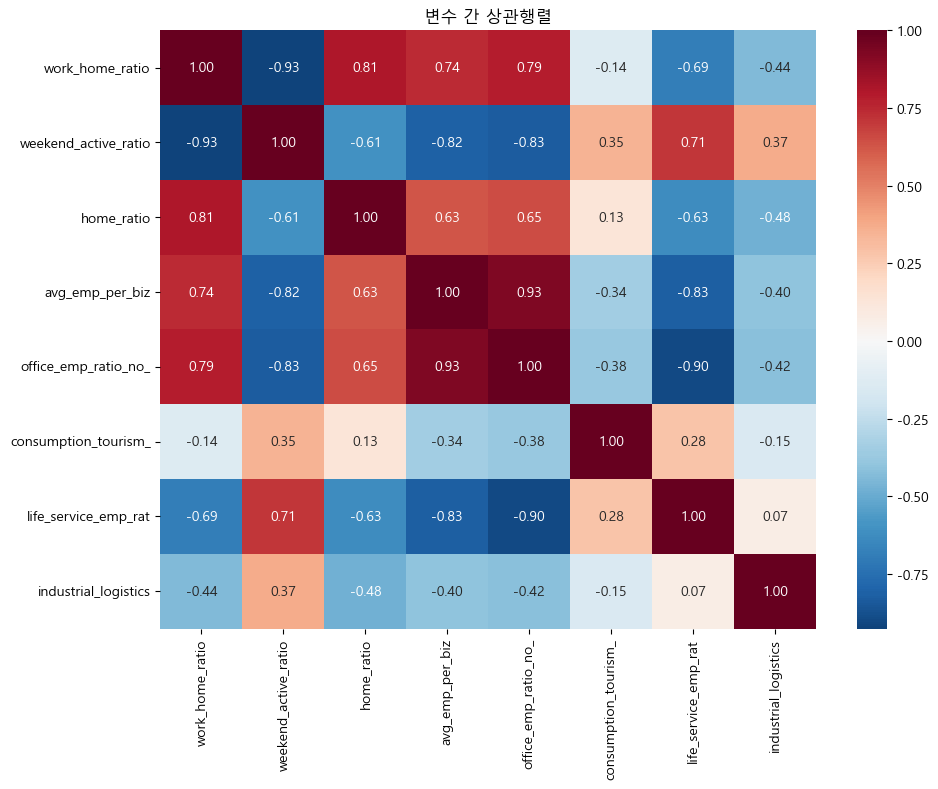

=== 그룹별 PCA 합성 ===
단독 변수: ['B3_consumption_tourism_emp_ratio', 'B4_life_service_emp_ratio', 'B5_industrial_logistics_emp_ratio']
PC_생활인구: ['L1_work_home_ratio', 'L2_weekend_active_ratio', 'weekend_home_ratio']
PC_사업체구조: ['B1_avg_emp_per_biz', 'B2_office_emp_ratio_no_support']


In [7]:
# ============================================================
# 2. 상관행렬 확인 + 상관 높은 변수 그룹별 PCA 합성
# ============================================================
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- 2-1. 상관행렬 시각화 ---
corr = model_df[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            xticklabels=[c.split("_", 1)[-1][:20] for c in features],
            yticklabels=[c.split("_", 1)[-1][:20] for c in features])
plt.title("변수 간 상관행렬")
plt.tight_layout()
plt.show()

# --- 2-2. 상관 높은 변수 그룹 정의 (직접 확인 후 수정 가능) ---
# 그룹 내 변수들을 PCA 1성분으로 합성, 나머지는 그대로 사용
variable_groups = {
    "PC_생활인구": ["L1_work_home_ratio", "L2_weekend_active_ratio", "weekend_home_ratio"],
    "PC_사업체구조": ["B1_avg_emp_per_biz", "B2_office_emp_ratio_no_support"],
}

# 그룹에 안 들어간 변수는 단독 사용
grouped_vars = [v for g in variable_groups.values() for v in g]
standalone = [c for c in features if c not in grouped_vars]

print("=== 그룹별 PCA 합성 ===")
print("단독 변수:", standalone)
for k, v in variable_groups.items():
    print(f"{k}: {v}")


# PCA 방안
- 상관관계가 높은 변수들은 PCA를 통해 차원축소
- 일단 단독으로 남길 것 : 'B3_consumption_tourism_emp_ratio', 'B4_life_service_emp_ratio', 'B5_industrial_logistics_emp_ratio'
- PC_생활인구: 
- work_home_ratio (직주비율)
- weekend_active_ratio (주말 활동 비율)
- home_ratio (주거 비율)
- avg_emp_per_biz (사업체당 평균 종사자 수)
- office_emp_ratio_no_ (오피스 종사자 비율)
- life_service_emp_rat (생활 서비스 종사자 비율) 축 하나


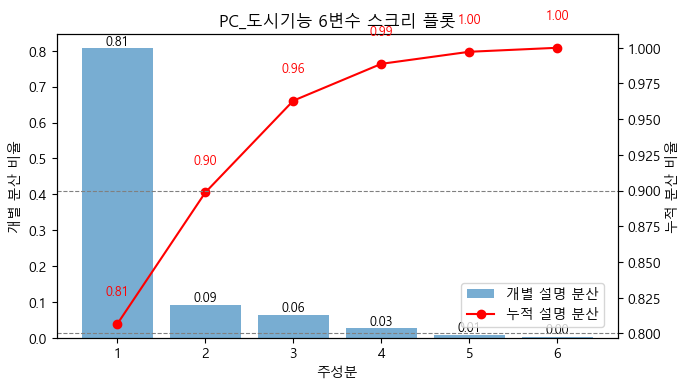


=== 주성분 적재량 (Loadings) ===


,변수,PC1,PC2,PC3,PC4,PC5,PC6
L1_work_home_ratio,work_home_ratio,+0.417,+0.418,+0.341,-0.212,+0.012,+0.700
L2_weekend_active_ratio,weekend_active_ratio,-0.414,-0.032,-0.642,+0.131,+0.139,+0.616
weekend_home_ratio,home_ratio,+0.361,+0.681,-0.526,+0.183,+0.002,-0.310
B1_avg_emp_per_biz,avg_emp_per_biz,+0.419,-0.341,-0.018,+0.711,-0.409,+0.186
B2_office_emp_ratio_no_support,office_emp_ratio_no_suppo,+0.432,-0.323,-0.083,+0.073,+0.834,-0.016
B4_life_service_emp_ratio,life_service_emp_ratio,-0.402,+0.375,+0.433,+0.627,+0.342,-0.010



→ PC1만 사용 시 설명 분산: 80.7%
→ PC1+PC2 사용 시 설명 분산: 89.9%


In [8]:
# ============================================================
# PC_도시기능 6개 변수 PCA 상세 결과
# ============================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_vars = [
    "L1_work_home_ratio",
    "L2_weekend_active_ratio",
    "weekend_home_ratio",
    "B1_avg_emp_per_biz",
    "B2_office_emp_ratio_no_support",
    "B4_life_service_emp_ratio",
]

scaler = StandardScaler()
X_pca = scaler.fit_transform(model_df[pca_vars])

pca_full = PCA()
pca_full.fit(X_pca)

# --- 스크리 플롯 ---
evr = pca_full.explained_variance_ratio_
cumsum = np.cumsum(evr)

fig, ax1 = plt.subplots(figsize=(7, 4))
x = range(1, len(evr)+1)
ax1.bar(x, evr, alpha=0.6, label="개별 설명 분산")
ax2 = ax1.twinx()
ax2.plot(x, cumsum, "ro-", label="누적 설명 분산")
ax2.axhline(0.8, color="gray", ls="--", lw=0.8)
ax2.axhline(0.9, color="gray", ls="--", lw=0.8)

for i, (v, c) in enumerate(zip(evr, cumsum)):
    ax1.text(i+1, v+0.01, f"{v:.2f}", ha="center", fontsize=9)
    ax2.text(i+1, c+0.02, f"{c:.2f}", ha="center", fontsize=9, color="red")

ax1.set_xlabel("주성분"); ax1.set_ylabel("개별 분산 비율")
ax2.set_ylabel("누적 분산 비율")
ax1.set_xticks(list(x))
plt.title("PC_도시기능 6변수 스크리 플롯")
fig.legend(loc="lower right", bbox_to_anchor=(0.88, 0.15))
plt.tight_layout(); plt.show()

# --- 적재량(loadings) 테이블 ---
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=pca_vars,
    columns=[f"PC{i+1}" for i in range(len(evr))]
)
loadings["변수"] = [v.split("_", 1)[-1][:25] for v in pca_vars]
loadings = loadings[["변수"] + [f"PC{i+1}" for i in range(len(evr))]]

print("\n=== 주성분 적재량 (Loadings) ===")
display(loadings.style.format({c: "{:+.3f}" for c in loadings.columns if c.startswith("PC")}))

print(f"\n→ PC1만 사용 시 설명 분산: {evr[0]:.1%}")
print(f"→ PC1+PC2 사용 시 설명 분산: {cumsum[1]:.1%}")

최종 변수 (4개): ['PC1_도시기능', 'PC2_도시기능', 'consumption_tourism', 'industrial_logistics']
X shape: (25, 4)


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K=2  silhouette=0.4611


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K=3  silhouette=0.4156


...

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K=6  silhouette=0.3618


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K=7  silhouette=0.3544

최적 K = 2 (silhouette=0.4611)


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


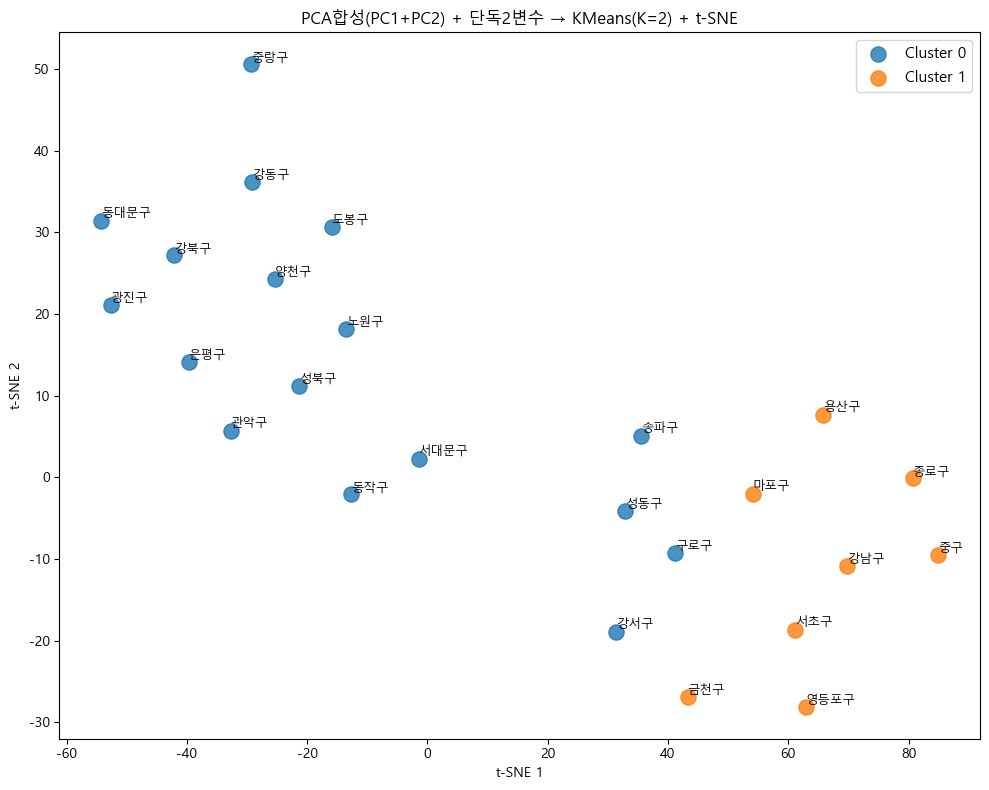


=== 클러스터별 구 ===
Cluster 0: 성동구, 광진구, 동대문구, 중랑구, 성북구, 강북구, 도봉구, 노원구, 은평구, 서대문구, 양천구, 강서구, 구로구, 동작구, 관악구, 송파구, 강동구
Cluster 1: 종로구, 중구, 용산구, 마포구, 금천구, 영등포구, 서초구, 강남구


In [9]:
# ============================================================
# PC1, PC2 + 단독변수 2개 → 총 4변수로 t-SNE
# ============================================================

# PCA 2성분 추출
pca2 = PCA(n_components=2)
pc_scores = pca2.fit_transform(X_pca)

# 최종 클러스터링 입력 조합
cluster_df = pd.DataFrame({
    "PC1_도시기능": pc_scores[:, 0],
    "PC2_도시기능": pc_scores[:, 1],
    "consumption_tourism": scaler.fit_transform(model_df[["B3_consumption_tourism_emp_ratio"]])[:, 0],
    "industrial_logistics": scaler.fit_transform(model_df[["B5_industrial_logistics_emp_ratio"]])[:, 0],
}, index=model_df.index)

X_final = cluster_df.values
final_features = list(cluster_df.columns)
print(f"최종 변수 ({len(final_features)}개): {final_features}")
print(f"X shape: {X_final.shape}")

# --- KMeans 실루엣 ---
sil_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init=30, random_state=42)
    labels = km.fit_predict(X_final)
    sil = silhouette_score(X_final, labels)
    sil_scores[k] = sil
    print(f"K={k}  silhouette={sil:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\n최적 K = {best_k} (silhouette={sil_scores[best_k]:.4f})")

# --- 최종 클러스터링 + t-SNE ---
km_final = KMeans(n_clusters=best_k, n_init=30, random_state=42)
model_df["cluster_new"] = km_final.fit_predict(X_final)

tsne = TSNE(n_components=2, perplexity=min(8, len(X_final)-1), random_state=42, init="pca")
emb = tsne.fit_transform(X_final)

plt.figure(figsize=(10, 8))
for cl in sorted(model_df["cluster_new"].unique()):
    mask = model_df["cluster_new"] == cl
    plt.scatter(emb[mask, 0], emb[mask, 1], s=120, label=f"Cluster {cl}", alpha=0.8)
    for i in model_df.index[mask]:
        idx = model_df.index.get_loc(i)
        plt.annotate(model_df.loc[i, "gu"], (emb[idx, 0], emb[idx, 1]),
                     fontsize=9, ha="left", va="bottom")

plt.legend(fontsize=11)
plt.title(f"PCA합성(PC1+PC2) + 단독2변수 → KMeans(K={best_k}) + t-SNE")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.tight_layout(); plt.show()

# 클러스터별 구 목록
print("\n=== 클러스터별 구 ===")
for cl in sorted(model_df["cluster_new"].unique()):
    gus = model_df.loc[model_df["cluster_new"] == cl, "gu"].tolist()
    print(f"Cluster {cl}: {', '.join(gus)}")

초기 중심점 구: ['강남구', '노원구', '광진구', '성동구']
Shape: (4, 4)


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


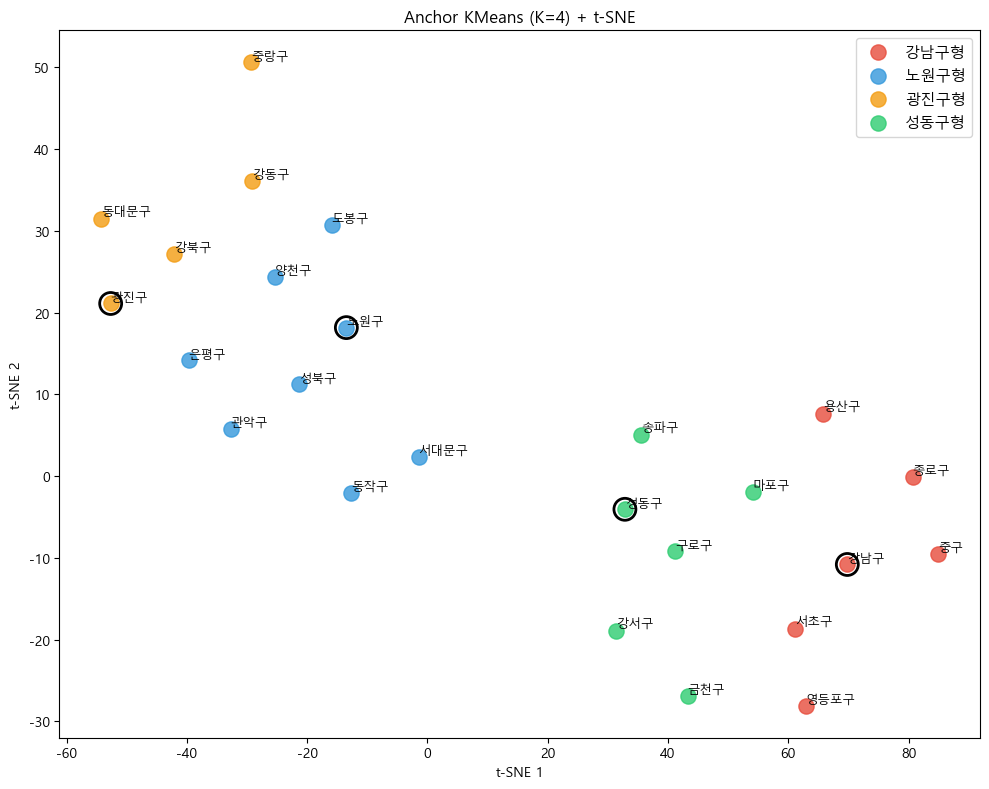


=== 클러스터별 구 ===
강남구형: 종로구, 중구, 용산구, 영등포구, 서초구, 강남구
노원구형: 성북구, 도봉구, 노원구, 은평구, 서대문구, 양천구, 동작구, 관악구
광진구형: 광진구, 동대문구, 중랑구, 강북구, 강동구
성동구형: 성동구, 마포구, 강서구, 구로구, 금천구, 송파구


In [10]:
# ============================================================
# K=4, 초기 중심점: 강남구, 노원구, 광진구, 성동구
# ============================================================

anchor_gus = ["강남구", "노원구", "광진구", "성동구"]

# 초기 중심점 추출
init_centers = np.array([
    X_final[model_df[model_df["gu"] == gu].index[0] - model_df.index[0]]
    for gu in anchor_gus
])

print("초기 중심점 구:", anchor_gus)
print("Shape:", init_centers.shape)

# KMeans with custom init
km_anchor = KMeans(n_clusters=4, init=init_centers, n_init=1, random_state=42)
model_df["cluster_anchor"] = km_anchor.fit_predict(X_final)

# --- t-SNE 시각화 ---
tsne = TSNE(n_components=2, perplexity=min(8, len(X_final)-1), random_state=42, init="pca")
emb = tsne.fit_transform(X_final)

label_map = {i: f"{anchor_gus[i]}형" for i in range(4)}
colors = ["#e74c3c", "#3498db", "#f39c12", "#2ecc71"]

plt.figure(figsize=(10, 8))
for cl in range(4):
    mask = model_df["cluster_anchor"] == cl
    plt.scatter(emb[mask, 0], emb[mask, 1], s=120, c=colors[cl],
                label=label_map[cl], alpha=0.8)
    for i in model_df.index[mask]:
        idx = model_df.index.get_loc(i)
        gu_name = model_df.loc[i, "gu"]
        # 앵커 구는 강조 표시
        if gu_name in anchor_gus:
            plt.scatter(emb[idx, 0], emb[idx, 1], s=250, facecolors="none",
                        edgecolors="black", linewidths=2)
        plt.annotate(gu_name, (emb[idx, 0], emb[idx, 1]),
                     fontsize=9, ha="left", va="bottom")

plt.legend(fontsize=11)
plt.title("Anchor KMeans (K=4) + t-SNE")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.tight_layout(); plt.show()

# 클러스터별 구 목록
print("\n=== 클러스터별 구 ===")
for cl in range(4):
    gus = model_df.loc[model_df["cluster_anchor"] == cl, "gu"].tolist()
    print(f"{label_map[cl]}: {', '.join(gus)}")

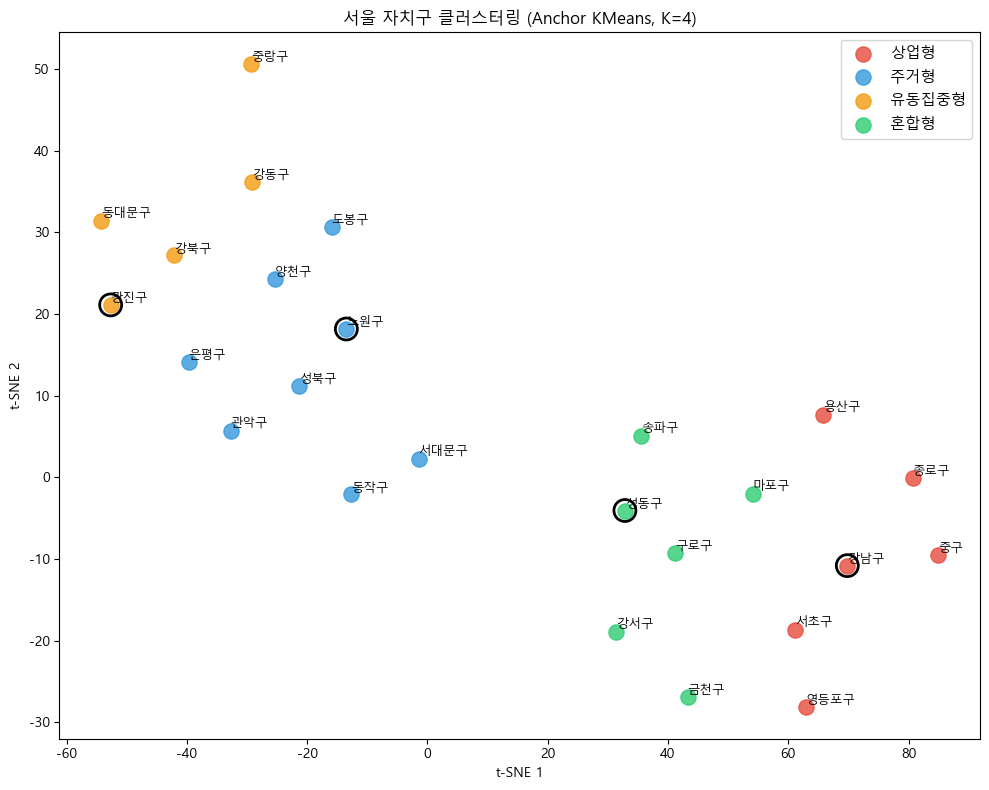


=== 클러스터별 구 ===
상업형: 종로구, 중구, 용산구, 영등포구, 서초구, 강남구
주거형: 성북구, 도봉구, 노원구, 은평구, 서대문구, 양천구, 동작구, 관악구
유동집중형: 광진구, 동대문구, 중랑구, 강북구, 강동구
혼합형: 성동구, 마포구, 강서구, 구로구, 금천구, 송파구

→ cluster_result.csv 저장 완료


,gu,cluster_anchor,cluster_type,L1_work_home_ratio,L2_weekend_active_ratio,weekend_home_ratio,B1_avg_emp_per_biz,B2_office_emp_ratio_no_support,B3_consumption_tourism_emp_ratio,B4_life_service_emp_ratio,B5_industrial_logistics_emp_ratio,PC1_도시기능,PC2_도시기능
0,종로구,0,상업형,1.639698,0.795812,1.120581,5.672325,0.307603,0.270190,0.158138,0.132324,3.458148,1.960962
1,중구,0,상업형,2.064828,0.629787,1.083157,5.960833,0.410461,0.276900,0.074487,0.119097,5.194560,1.344587
2,용산구,0,상업형,1.184049,0.975406,1.076227,5.656782,0.311226,0.344603,0.141911,0.084112,1.909782,0.504961
3,성동구,3,혼합형,1.092607,0.911819,0.982540,5.119779,0.264219,0.266925,0.150575,0.206280,0.829732,-0.715104
4,광진구,2,유동집중형,0.937800,1.047381,0.982846,3.768584,0.143997,0.298187,0.273648,0.181917,-1.289669,0.229185
5,동대문구,2,유동집중형,0.982189,0.977135,0.971601,3.378678,0.124829,0.317755,0.284616,0.179222,-1.331756,0.346242
6,중랑구,2,유동집중형,0.847549,1.097254,0.967456,2.727116,0.076985,0.272712,0.268140,0.302640,-2.305739,0.312982
7,성북구,1,주거형,0.897531,1.021568,0.951521,3.531200,0.122407,0.262859,0.367205,0.155216,-2.065834,0.189028
8,강북구,2,유동집중형,0.873287,1.080638,0.976905,2.953737,0.107578,0.302779,0.294023,0.199744,-2.043262,0.443315
9,도봉구,1,주거형,0.866140,1.096668,0.978875,3.165744,0.118359,0.249941,0.315619,0.194613,-2.066692,0.451756


In [11]:
# ============================================================
# 클러스터 라벨 매핑 + CSV 내보내기
# ============================================================

# 앵커 → 클러스터 유형 매핑
anchor_label = {
    "강남구": "상업형",
    "노원구": "주거형",
    "광진구": "유동집중형",
    "성동구": "혼합형",
}

# 클러스터 번호 → 유형 매핑 (앵커 구가 어떤 번호에 배정됐는지 역추적)
cluster_label_map = {}
for gu, label in anchor_label.items():
    cl_num = model_df.loc[model_df["gu"] == gu, "cluster_anchor"].values[0]
    cluster_label_map[cl_num] = label

model_df["cluster_type"] = model_df["cluster_anchor"].map(cluster_label_map)

# --- t-SNE 다시 그리기 (라벨 변경) ---
type_colors = {"상업형": "#e74c3c", "주거형": "#3498db", "유동집중형": "#f39c12", "혼합형": "#2ecc71"}

plt.figure(figsize=(10, 8))
for ctype, color in type_colors.items():
    mask = model_df["cluster_type"] == ctype
    plt.scatter(emb[mask, 0], emb[mask, 1], s=120, c=color, label=ctype, alpha=0.8)
    for i in model_df.index[mask]:
        idx = model_df.index.get_loc(i)
        gu_name = model_df.loc[i, "gu"]
        if gu_name in anchor_label:
            plt.scatter(emb[idx, 0], emb[idx, 1], s=250, facecolors="none",
                        edgecolors="black", linewidths=2)
        plt.annotate(gu_name, (emb[idx, 0], emb[idx, 1]),
                     fontsize=9, ha="left", va="bottom")

plt.legend(fontsize=11)
plt.title("서울 자치구 클러스터링 (Anchor KMeans, K=4)")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.tight_layout(); plt.show()

# --- 클러스터별 구 목록 ---
print("\n=== 클러스터별 구 ===")
for ctype in ["상업형", "주거형", "유동집중형", "혼합형"]:
    gus = model_df.loc[model_df["cluster_type"] == ctype, "gu"].tolist()
    print(f"{ctype}: {', '.join(gus)}")

# --- CSV 내보내기 ---
out_cols = ["gu", "cluster_anchor", "cluster_type"] + features
out_df = model_df[out_cols].copy()

# PCA 점수도 같이 내보내기 (회귀에 쓸 수 있도록)
out_df["PC1_도시기능"] = pc_scores[:, 0]
out_df["PC2_도시기능"] = pc_scores[:, 1]

out_df.to_csv("cluster_result.csv", index=False, encoding="utf-8-sig")
print("\n→ cluster_result.csv 저장 완료")
display(out_df)

In [15]:
# ============================================================
# 2. 강서구 별도 분리 여부
# ============================================================

EXCLUDE_GANGSEO = True

special_gu = ["강서구"]

if EXCLUDE_GANGSEO:
    fit_df = model_df[~model_df["gu"].isin(special_gu)].copy()
    special_df = model_df[model_df["gu"].isin(special_gu)].copy()
else:
    fit_df = model_df.copy()
    special_df = pd.DataFrame()

print("클러스터링 대상:", fit_df.shape)
print("별도 분리:", special_df["gu"].tolist() if len(special_df) > 0 else "없음")

클러스터링 대상: (24, 9)
별도 분리: ['강서구']


In [16]:
# ============================================================
# 3. 표준화
# ============================================================

X = fit_df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features,
    index=fit_df.index
)

display(X_scaled_df.head())

,L1_work_home_ratio,L2_weekend_active_ratio,weekend_home_ratio,B1_avg_emp_per_biz,B2_office_emp_ratio_no_support,B3_consumption_tourism_emp_ratio,B4_life_service_emp_ratio,B5_industrial_logistics_emp_ratio
0,1.922366,-1.336387,2.798255,0.914894,0.802863,0.095612,-0.764428,-0.717114
1,3.387473,-2.650550,1.975950,1.137322,1.759291,0.291326,-1.607935,-0.990634
2,0.352079,0.085182,1.823671,0.902911,0.836555,2.266074,-0.928061,-1.714059
3,0.036947,-0.418139,-0.234872,0.488905,0.399457,0.000361,-0.840693,0.812146
4,-0.496559,0.654898,-0.228158,-0.552809,-0.718423,0.912216,0.400342,0.308361


In [21]:
# ============================================================
# 4. 도메인 대표구 초기값 설정
# ============================================================

representative_gu = {
    "주거형": "은평구",
    "상업형": "송파구",
    "유동인구형": "은평구",
    "혼합형": "마포구"
}

rep_order = list(representative_gu.keys())
rep_names = list(representative_gu.values())

# 대표구가 데이터에 있는지 확인
missing_reps = [g for g in rep_names if g not in fit_df["gu"].values]

if len(missing_reps) > 0:
    raise ValueError(f"대표구가 클러스터링 대상에 없습니다: {missing_reps}")

print("대표구:")
for k, v in representative_gu.items():
    print(f"{k}: {v}")

대표구:
주거형: 은평구
상업형: 송파구
유동인구형: 은평구
혼합형: 마포구


In [22]:
# ============================================================
# 5. 대표구 초기값 KMeans
# ============================================================

gu_to_pos = {gu: i for i, gu in enumerate(fit_df["gu"])}

init_indices = [gu_to_pos[g] for g in rep_names]
init_centers = X_scaled[init_indices]

anchor_kmeans = KMeans(
    n_clusters=len(rep_names),
    init=init_centers,
    n_init=1,
    random_state=42,
    max_iter=300
)

fit_df["anchor_cluster"] = anchor_kmeans.fit_predict(X_scaled)

# cluster 번호를 대표 유형명으로 매핑
cluster_to_type = {i: rep_order[i] for i in range(len(rep_order))}
fit_df["anchor_type"] = fit_df["anchor_cluster"].map(cluster_to_type)

# 강서구 다시 붙이기
if EXCLUDE_GANGSEO and len(special_df) > 0:
    special_df = special_df.copy()
    special_df["anchor_cluster"] = -1
    special_df["anchor_type"] = "산업단지 특이형"
    
    anchor_result = pd.concat([fit_df, special_df], ignore_index=True)
else:
    anchor_result = fit_df.copy()

display(
    anchor_result[["gu", "anchor_cluster", "anchor_type"]]
    .sort_values(["anchor_cluster", "gu"])
)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,gu,anchor_cluster,anchor_type
24,강서구,-1,산업단지 특이형
23,강동구,0,주거형
8,강북구,0,주거형
19,관악구,0,주거형
4,광진구,0,주거형
10,노원구,0,주거형
9,도봉구,0,주거형
5,동대문구,0,주거형
18,동작구,0,주거형
12,서대문구,0,주거형


In [23]:
# ============================================================
# 6. 유형별 자치구 목록
# ============================================================

for t in anchor_result["anchor_type"].unique():
    temp = anchor_result[anchor_result["anchor_type"] == t]["gu"].tolist()
    print(f"\n[{t}] {len(temp)}개")
    print(", ".join(temp))


[혼합형] 6개
종로구, 용산구, 마포구, 영등포구, 서초구, 강남구

[유동인구형] 1개
중구

[상업형] 4개
성동구, 구로구, 금천구, 송파구

[주거형] 13개
광진구, 동대문구, 중랑구, 성북구, 강북구, 도봉구, 노원구, 은평구, 서대문구, 양천구, 동작구, 관악구, 강동구

[산업단지 특이형] 1개
강서구


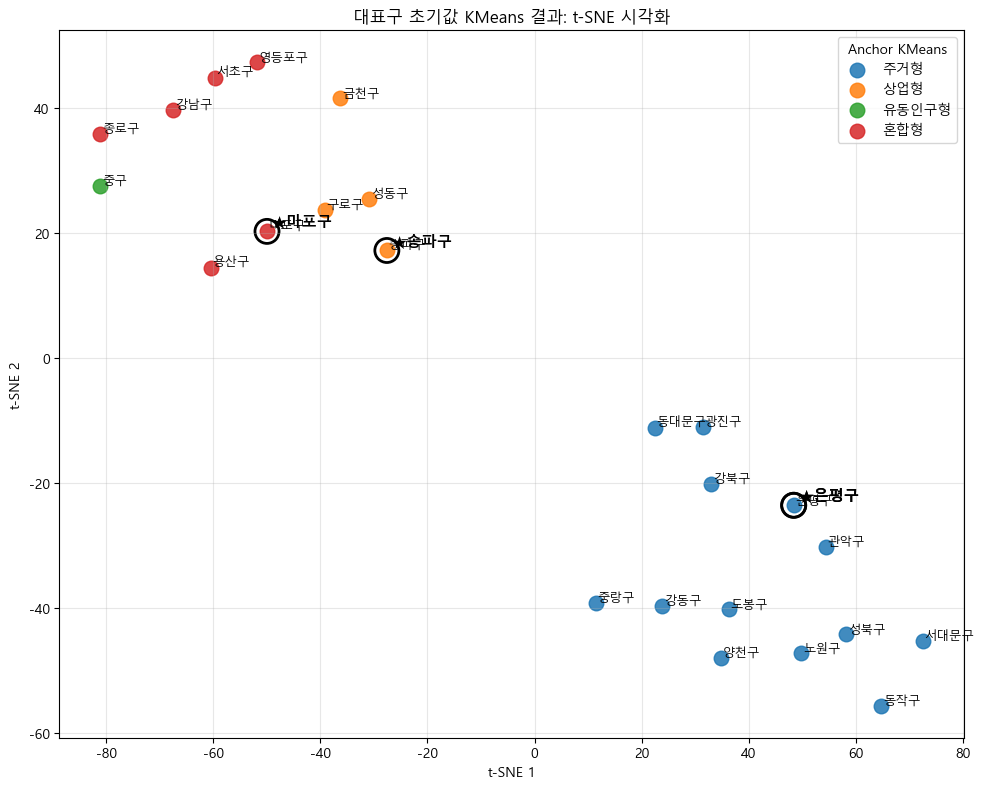

In [24]:
# ============================================================
# 10. t-SNE 시각화
# ============================================================

tsne = TSNE(
    n_components=2,
    perplexity=5,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_result = tsne.fit_transform(X_scaled)

fit_df["TSNE1"] = tsne_result[:, 0]
fit_df["TSNE2"] = tsne_result[:, 1]

plt.figure(figsize=(10, 8))

for t in rep_order:
    temp = fit_df[fit_df["anchor_type"] == t]
    plt.scatter(
        temp["TSNE1"],
        temp["TSNE2"],
        s=110,
        label=t,
        alpha=0.85
    )

for _, row in fit_df.iterrows():
    plt.text(
        row["TSNE1"] + 0.3,
        row["TSNE2"] + 0.3,
        row["gu"],
        fontsize=9
    )

for t, gu in representative_gu.items():
    row = fit_df[fit_df["gu"] == gu].iloc[0]
    plt.scatter(
        row["TSNE1"],
        row["TSNE2"],
        s=300,
        facecolors="none",
        edgecolors="black",
        linewidths=2
    )
    plt.text(
        row["TSNE1"] + 0.8,
        row["TSNE2"] + 0.8,
        f"★{gu}",
        fontsize=11,
        fontweight="bold"
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("대표구 초기값 KMeans 결과: t-SNE 시각화")
plt.legend(title="Anchor KMeans")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# DBSCAN

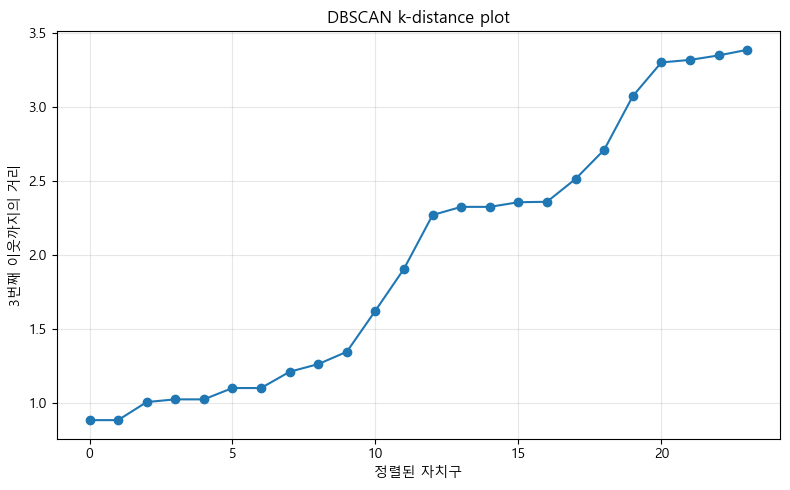

,gu,k_distance
16,금천구,3.382977
2,용산구,3.345218
1,중구,3.314963
0,종로구,3.298001
21,강남구,3.069931
17,영등포구,2.707447
13,마포구,2.511016
6,중랑구,2.356560
3,성동구,2.353565
22,송파구,2.322217


In [11]:
# ============================================================
# 11. DBSCAN eps 후보 찾기: k-distance plot
# ============================================================

min_samples = 3

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

# 각 점의 k번째 이웃 거리
k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances, marker="o")
plt.xlabel("정렬된 자치구")
plt.ylabel(f"{min_samples}번째 이웃까지의 거리")
plt.title("DBSCAN k-distance plot")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "gu": fit_df["gu"].values,
    "k_distance": distances[:, min_samples - 1]
}).sort_values("k_distance", ascending=False))

In [12]:
# ============================================================
# 12. eps별 DBSCAN 결과 비교
# ============================================================

scan_results = []

for eps in np.arange(1.0, 5.1, 0.25):
    db = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )
    
    labels = db.fit_predict(X_scaled)
    
    n_noise = np.sum(labels == -1)
    n_cluster = len(set(labels)) - (1 if -1 in labels else 0)
    
    scan_results.append({
        "eps": round(eps, 2),
        "n_cluster": n_cluster,
        "n_noise": n_noise,
        "labels": labels
    })

scan_df = pd.DataFrame(scan_results)

display(scan_df[["eps", "n_cluster", "n_noise"]])

# 적당한 후보만 보기
display(
    scan_df[
        (scan_df["n_cluster"].between(2, 5)) &
        (scan_df["n_noise"] <= 10)
    ][["eps", "n_cluster", "n_noise"]]
)

,eps,n_cluster,n_noise
0,1.00,1,20
1,1.25,1,14
2,1.50,1,14
3,1.75,1,12
4,2.00,1,12
5,2.25,1,12
6,2.50,2,4
7,2.75,1,3
8,3.00,1,2
9,3.25,1,1


,eps,n_cluster,n_noise
6,2.5,2,4


In [13]:
# ============================================================
# 13. DBSCAN 최종 실행
# ============================================================

dbscan_eps = 2.5

dbscan = DBSCAN(
    eps=dbscan_eps,
    min_samples=min_samples
)

fit_df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

print("DBSCAN 결과")
print(fit_df["dbscan_cluster"].value_counts().sort_index())

for k in sorted(fit_df["dbscan_cluster"].unique()):
    temp = fit_df[fit_df["dbscan_cluster"] == k]["gu"].tolist()
    
    if k == -1:
        print(f"\n[Noise / 이상치] {len(temp)}개")
    else:
        print(f"\n[DBSCAN Cluster {k}] {len(temp)}개")
        
    print(", ".join(temp))

DBSCAN 결과
dbscan_cluster
-1     4
 0    17
 1     3
Name: count, dtype: int64

[Noise / 이상치] 4개
종로구, 중구, 용산구, 금천구

[DBSCAN Cluster 0] 17개
성동구, 광진구, 동대문구, 중랑구, 성북구, 강북구, 도봉구, 노원구, 은평구, 서대문구, 마포구, 양천구, 구로구, 동작구, 관악구, 송파구, 강동구

[DBSCAN Cluster 1] 3개
영등포구, 서초구, 강남구
